Loading California Housing dataset...
Performing feature engineering...
Splitting and scaling the data...
Training multiple machine learning models...


--- Model Evaluation Results ---
            Model      MAE     RMSE  R2 Score
    Decision Tree 0.436756 0.665935  0.661579
Linear Regression 0.502854 0.695772  0.630574
 Ridge Regression 0.502855 0.695778  0.630567
----------------------------------------
🏆 Best Model: Decision Tree (R2 Score = 0.6616)

Saved evaluation results to 'model_comparison.csv'.
Generating performance visualizations...


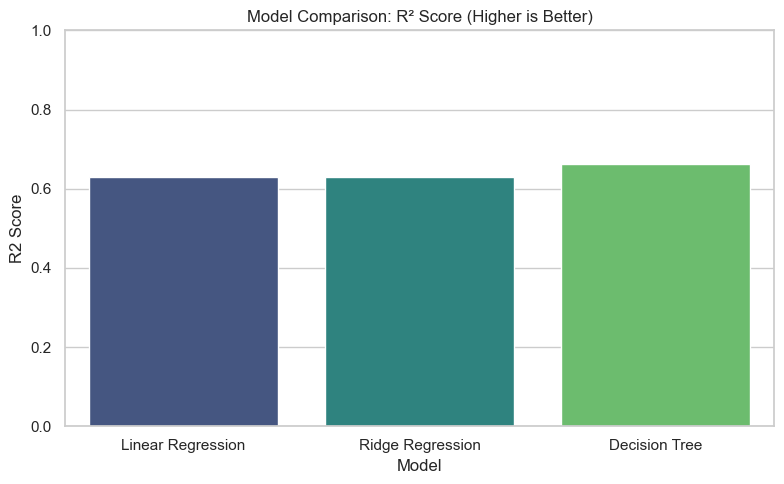

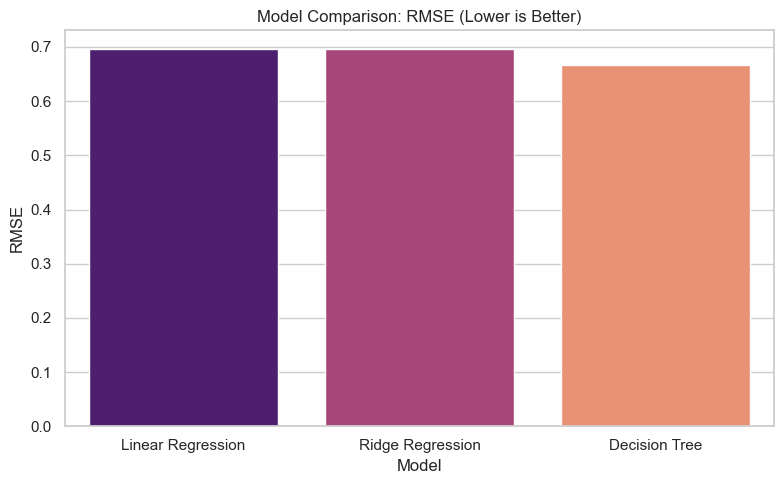

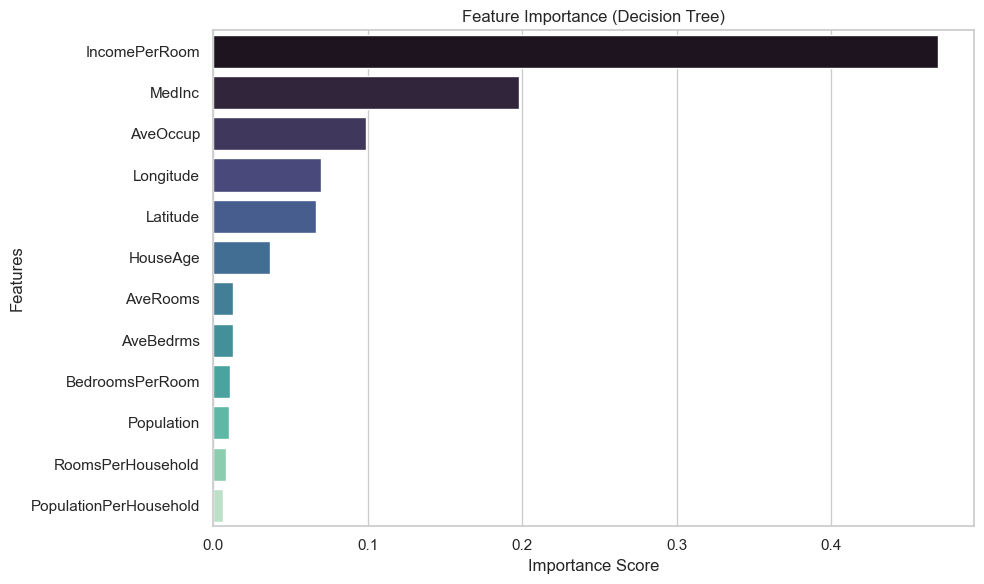

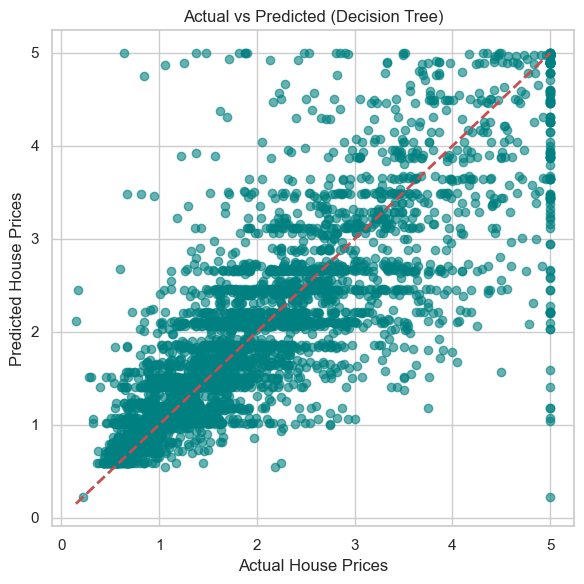

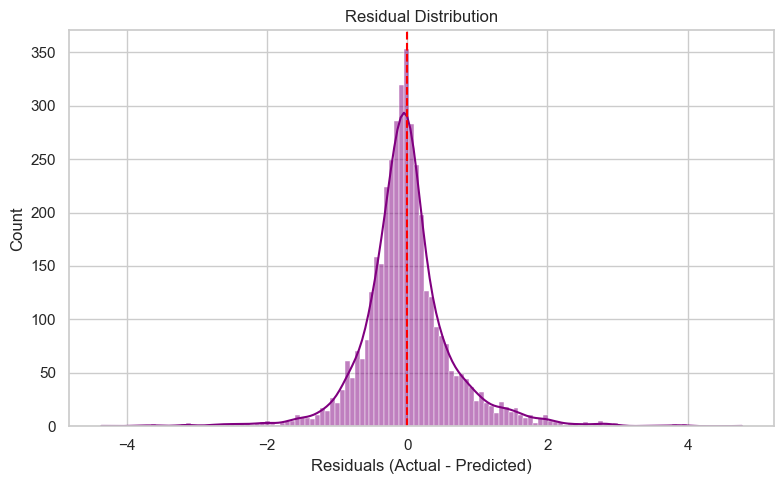

Saving the best model and scaler...
Assets saved successfully.

✅ Script execution completed successfully!


In [ ]:
# 1. Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")

# 2. Load the Dataset
print("Loading California Housing dataset...")
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

# 3. Feature Engineering
print("Performing feature engineering...")

expected_columns = [
    "AveRooms",
    "AveBedrms",
    "Population",
    "MedInc",
    "AveOccup",
    "HouseAge"
]

for column in expected_columns:
    if column not in df.columns:
        raise ValueError(f"Missing expected column: {column}")

df["RoomsPerHousehold"] = df["AveRooms"] / df["HouseAge"]
df["BedroomsPerRoom"] = df["AveBedrms"] / df["AveRooms"]
df["PopulationPerHousehold"] = df["Population"] / df["AveOccup"]
df["IncomePerRoom"] = df["MedInc"] / df["AveRooms"]

# 4. Data Preparation
print("Splitting and scaling the data...")

X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Model Training & Comparison
print("Training multiple machine learning models...\n")

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    )
}

results = []
best_model = None
best_r2 = -float("inf")
best_model_name = ""

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    mae_value = mean_absolute_error(y_test, y_pred)
    rmse_value = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_value = r2_score(y_test, y_pred)

    results.append([
        name,
        mae_value,
        rmse_value,
        r2_value
    ])

    if r2_value > best_r2:
        best_r2 = r2_value
        best_model = model
        best_model_name = name

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

print("\n--- Model Evaluation Results ---")
print(results_df.sort_values(
    by="R2 Score",
    ascending=False
).to_string(index=False))

print("-" * 40)
print(f"🏆 Best Model: {best_model_name} (R2 Score = {best_r2:.4f})")

results_df.to_csv("model_comparison.csv", index=False)
print("\nSaved evaluation results to 'model_comparison.csv'.")

# 6. Visualizations
print("Generating performance visualizations...")

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Model Comparison: R² Score (Higher is Better)")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

# RMSE Comparison
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE",
    hue="Model",
    palette="magma",
    legend=False
)

plt.title("Model Comparison: RMSE (Lower is Better)")
plt.tight_layout()
plt.show()

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": models["Decision Tree"].feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="mako",
    legend=False
)

plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

best_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    best_pred,
    alpha=0.6,
    color="teal"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.tight_layout()
plt.show()

residuals = y_test - best_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True,
    color="purple"
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Distribution")
plt.xlabel("Residuals (Actual - Predicted)")
plt.tight_layout()
plt.show()

# 7. Save Model
print("Saving the best model and scaler...")

joblib.dump(best_model, "best_model.joblib")
joblib.dump(scaler, "scaler.joblib")

print("Assets saved successfully.")

production_pipeline = Pipeline([
    ("Scaler", StandardScaler()),
    ("Model", Ridge(alpha=1.0))
])

production_pipeline.fit(X_train, y_train)

print("\n✅ Script execution completed successfully!")